In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.feature_selection import SelectKBest, f_classif

In [3]:
df=pd.read_csv("C:/Users/shami/Downloads/archive/creditcard.csv")
df = df.sample(n=50000, random_state=42)

X = df.drop("Class", axis=1)
y = df["Class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
model_all = LogisticRegression(max_iter=200, n_jobs=-1)
model_all.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200, n_jobs=-1)

In [7]:
y_pred_all = model_all.predict(X_test_scaled)

print("All Features Model:")
print(classification_report(y_test, y_pred_all))

All Features Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.90      0.53      0.67        17

    accuracy                           1.00     10000
   macro avg       0.95      0.76      0.83     10000
weighted avg       1.00      1.00      1.00     10000



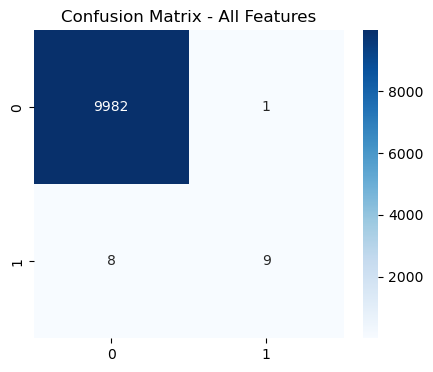

In [10]:
cm_all = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(5,4))
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - All Features")
plt.savefig("C:/Users/shami/Downloads/Project/Feature-selection/results/cm_all_features.png")
plt.show()

In [11]:
selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

In [12]:
model_selected = LogisticRegression(max_iter=200, n_jobs=-1)
model_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=200, n_jobs=-1)

In [13]:
y_pred_selected = model_selected.predict(X_test_selected)

print("Selected Features Model:")
print(classification_report(y_test, y_pred_selected))

Selected Features Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.88      0.41      0.56        17

    accuracy                           1.00     10000
   macro avg       0.94      0.71      0.78     10000
weighted avg       1.00      1.00      1.00     10000



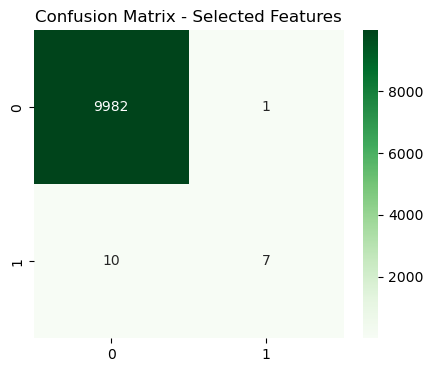

In [16]:
cm_selected = confusion_matrix(y_test, y_pred_selected)

plt.figure(figsize=(5,4))
sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Selected Features")
plt.savefig("C:/Users/shami/Downloads/Project/Feature-selection/results/cm_selected_features.png")
plt.show()

In [17]:
report_all = classification_report(y_test, y_pred_all, output_dict=True)
report_selected = classification_report(y_test, y_pred_selected, output_dict=True)

comparison = pd.DataFrame({
    "Recall_All_Features": [report_all['1']['recall']],
    "Recall_Selected_Features": [report_selected['1']['recall']]
}, index=["Fraud Class"])

print("\nRecall Comparison:")
print(comparison)


Recall Comparison:
             Recall_All_Features  Recall_Selected_Features
Fraud Class             0.529412                  0.411765
